In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
%pwd

'c:\\einos\\ml-course-workspace\\linear_regression'

In [4]:
df = pd.read_csv('house_prices.csv')
df

,area,price_in_lakhs
0,1460,59.82
1,1894,74.00
2,1730,68.34
3,1695,65.02
4,2238,85.98
...,...,...
95,1967,77.55
96,1752,62.97
97,2627,99.65
98,3295,127.81


In [5]:
X = df['area'].values #independent variable
y = df['price_in_lakhs'].values #dependent variable
X

array([1460, 1894, 1730, 1695, 2238, 2769, 1066, 1838,  930, 2082, 2735,
        730, 2285, 1369, 2991, 2115, 3453, 3033, 1815, 1555, 2924, 1784,
       1059,  621, 2900, 1347, 1074, 1682, 3158, 2647, 3347, 1575, 2406,
        789, 3334, 1162, 2499, 1867, 3479, 2128, 1246, 2668, 3488, 2814,
       1897, 3035, 1200, 2963, 2661,  841, 2641, 3424, 3212, 1963, 2739,
       1990, 2078, 3156, 1375,  634, 2853, 2555, 2185, 1621, 3213, 1729,
       2100, 1302, 3049, 3377, 2179,  761,  801, 2581, 1595, 2917, 1415,
       1055, 1875, 1616, 2943, 3367,  937, 1478, 1676, 1391, 2864, 1363,
       2835,  979, 1092, 1780, 2662,  664, 3168, 1967, 1752, 2627, 3295,
       2095])

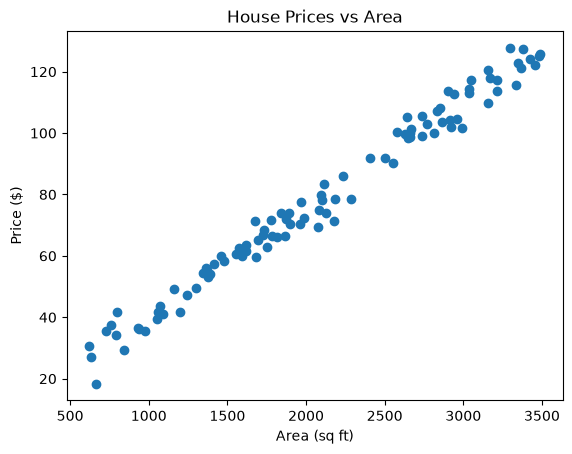

<Figure size 800x400 with 0 Axes>

In [6]:
plt.scatter(X, y)
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.title('House Prices vs Area')
plt.figure(figsize=(8, 4))
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.reshape(-1, 1) # Reshape X_train to be a 2D array with one column
X_test = X_test.reshape(-1, 1) # Reshape X_test to be a 2D array with one column

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.849
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[7588.02]


In [9]:
model.coef_ #slope

array([0.03471517])

In [10]:
model.intercept_ #intercept

np.float64(5.849280821688765)

In [11]:
model.predict([[1500]]) #predicting price for 1500 sq ft area

array([57.92204084])

In [12]:
model.predict(X_test) #predicting price for y_test data

array([ 57.15830702,  73.9951661 ,  81.49364354, 111.20983192,
        71.70396466,  79.7231697 ,  42.61264939, 108.01603597,
       100.79527992,  56.5334339 ,  68.85732044, 122.04096601,
        95.44914322,  33.23955259,  43.75825011,  83.54183877,
        54.9712511 ,  42.4737887 ,  85.17345191,  60.52567884])

In [13]:
y_test #actual prices for the test data ||  see the difference between predicted and actual prices

array([ 58.24,  70.44,  71.27, 113.07,  70.36,  73.89,  41.83, 112.88,
       105.57,  59.82,  66.07, 122.69, 100.26,  34.06,  41.08,  85.98,
        57.44,  39.45,  78.68,  62.56])

In [14]:
model.score(X_test, y_test) # our model is explaining 95% of the variance in the test data, which is a good result.

0.9754235949421621

Thank Your
Mahfujur Rahman.